In [1]:
import os
from pathlib import Path
from datetime import datetime

import polars as pl
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm

from pytecgg import GNSSContext
from pytecgg.utils import download_nav_bkg
from pytecgg.parsing import read_rinex_nav, read_rinex_obs
from pytecgg.satellites import prepare_ephemeris, satellite_coordinates, calculate_ipp
from pytecgg.linear_combinations import calculate_linear_combinations
from pytecgg.tec_calibration import (
    extract_arcs,
    calculate_tec,
    calculate_vertical_equivalent,
)

nav_path = Path("./data/nav")
obs_path = Path("./data/calm-obs-nav/")
results_path = Path("./pytecgg-results/calm-north-america")

os.makedirs(nav_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)

In [2]:
def get_station_id(fid: str) -> str:
    # for i, c in enumerate(fid):
    #     if c.isnumeric():
    #         return fid[:i]
    # raise Exception("No station ID found")
    return fid[:4]

station_ids = set()
for f in os.listdir(obs_path):
    if not f.endswith(".25o"):
        continue
    
    station_ids.add(get_station_id(f))
    
station_ids

{'bdla',
 'daex',
 'iid2',
 'kvtx',
 'lto1',
 'nayx',
 'p001',
 'p003',
 'p066',
 'p500',
 'p796',
 'palx',
 'pb1y',
 'phjx',
 'pjzx',
 'plcx',
 'plpx',
 'pltx',
 'ptex',
 'quex',
 'sglg',
 'tnhm',
 'tnpp',
 'tsfx',
 'uagu',
 'usmx',
 'yuhg',
 'yumx'}

In [3]:
doys_seen = set()
for s_id in station_ids:
    for f in obs_path.glob(f"{s_id}*.25o"):
        try:
            doys_seen.add(int(f.name.replace(s_id, '').replace('0.25o', '')))
        except Exception as e:
            print(s_id, f)
            raise e
        
doys_seen = list(doys_seen)
doys_seen

[293, 294, 295, 296, 330, 331, 332, 333]

In [4]:
# download nav files
    # contained for every single satellite? could be used for any observations?

# doy = day of year
doys = [
    datetime(2025, 11, 10).timetuple().tm_yday,
    datetime(2025, 11, 11).timetuple().tm_yday    
]
download_nav_bkg(2025, doys=doys + doys_seen, output_path=nav_path)

In [5]:
# Consolidate navigation messages into a dictionary
nav_files = sorted(nav_path.glob("BRDC*.rnx.gz"))
full_nav = {}

for f in nav_files:
    day_nav = read_rinex_nav(f)
    for system, df_nav in day_nav.items():
        full_nav[system] = pl.concat(
            [full_nav.get(system, pl.DataFrame()), df_nav]
        )

In [6]:
full_nav

{'BEIDOU': shape: (11_645, 29)
 ┌─────────────────────┬─────┬──────────┬──────┬───┬────────────┬────────────┬──────────┬────────┐
 │ epoch               ┆ sv  ┆ accuracy ┆ aodc ┆ … ┆ tgd1b1b3   ┆ tgd2b2b3   ┆ toe      ┆ week   │
 │ ---                 ┆ --- ┆ ---      ┆ ---  ┆   ┆ ---        ┆ ---        ┆ ---      ┆ ---    │
 │ datetime[μs, UTC]   ┆ str ┆ f64      ┆ f64  ┆   ┆ f64        ┆ f64        ┆ f64      ┆ f64    │
 ╞═════════════════════╪═════╪══════════╪══════╪═══╪════════════╪════════════╪══════════╪════════╡
 │ 2025-10-20 00:00:00 ┆ 1   ┆ 2.0      ┆ 1.0  ┆ … ┆ -9.4000e-9 ┆ -1.4100e-8 ┆ 86400.0  ┆ 1033.0 │
 │ UTC                 ┆     ┆          ┆      ┆   ┆            ┆            ┆          ┆        │
 │ 2025-10-20 00:00:00 ┆ 2   ┆ 2.0      ┆ null ┆ … ┆ -4.8000e-9 ┆ -1.9800e-8 ┆ 86400.0  ┆ 1033.0 │
 │ UTC                 ┆     ┆          ┆      ┆   ┆            ┆            ┆          ┆        │
 │ 2025-10-20 00:00:00 ┆ 3   ┆ 2.0      ┆ 4.0  ┆ … ┆ -2.7000e-9 ┆ -1.3200e-8 ┆

In [8]:
station_results: dict[str, pl.DataFrame] = {}

for s_id in (pbar := tqdm(station_ids, desc="Pytecgg", total=len(station_ids))):
    pbar.set_description(f"Station {s_id}")
    if os.path.exists(results_path / f"{s_id}.csv"):
        station_results[s_id] = pl.read_csv(results_path / f"{s_id}.csv")
        continue
    
    station_obs = []
    ctx: GNSSContext
    for i, f in enumerate(obs_path.glob(f"{s_id}*o")):
        try:
            df_obs, rec_pos, rinex_version = read_rinex_obs(f)
        except BaseException as e:
            print(f"Error processing {f}", e)
            continue
            
        if i == 0:
            ctx = GNSSContext(
                receiver_pos=rec_pos,
                receiver_name=s_id,
                rinex_version=rinex_version,
                h_ipp=350_000,
                systems=['G', 'E', 'R'],
            )
        station_obs.append(df_obs)
    station_obs = pl.concat(station_obs)
    
    # Enrich context and compute coordinates
    ephem_dict = prepare_ephemeris(full_nav, ctx)
    df_coords = satellite_coordinates(station_obs["sv"], station_obs["epoch"], ephem_dict)

    # Extract arcs and compute satellites' geometry
    df_lc = calculate_linear_combinations(
        station_obs,
        ctx,
        selection_mode="availability",
    )
    df_arcs = extract_arcs(df_lc, ctx, min_arc_length=120).join(
        df_coords, on=["sv", "epoch"], how="left"
    )
    df_geom = calculate_ipp(df_arcs, ctx, min_elevation=20)

    # Final calibrated products
    df_cal = calculate_tec(df_geom, ctx=ctx)
    df_veq = calculate_vertical_equivalent(df_cal, ctx=ctx)
    
    df_veq.write_csv(results_path / f"{s_id}.csv")
    station_results[s_id] = df_veq

Station tnpp: 100%|██████████| 28/28 [00:17<00:00,  1.57it/s]


100%|██████████| 28/28 [00:35<00:00,  1.28s/it]


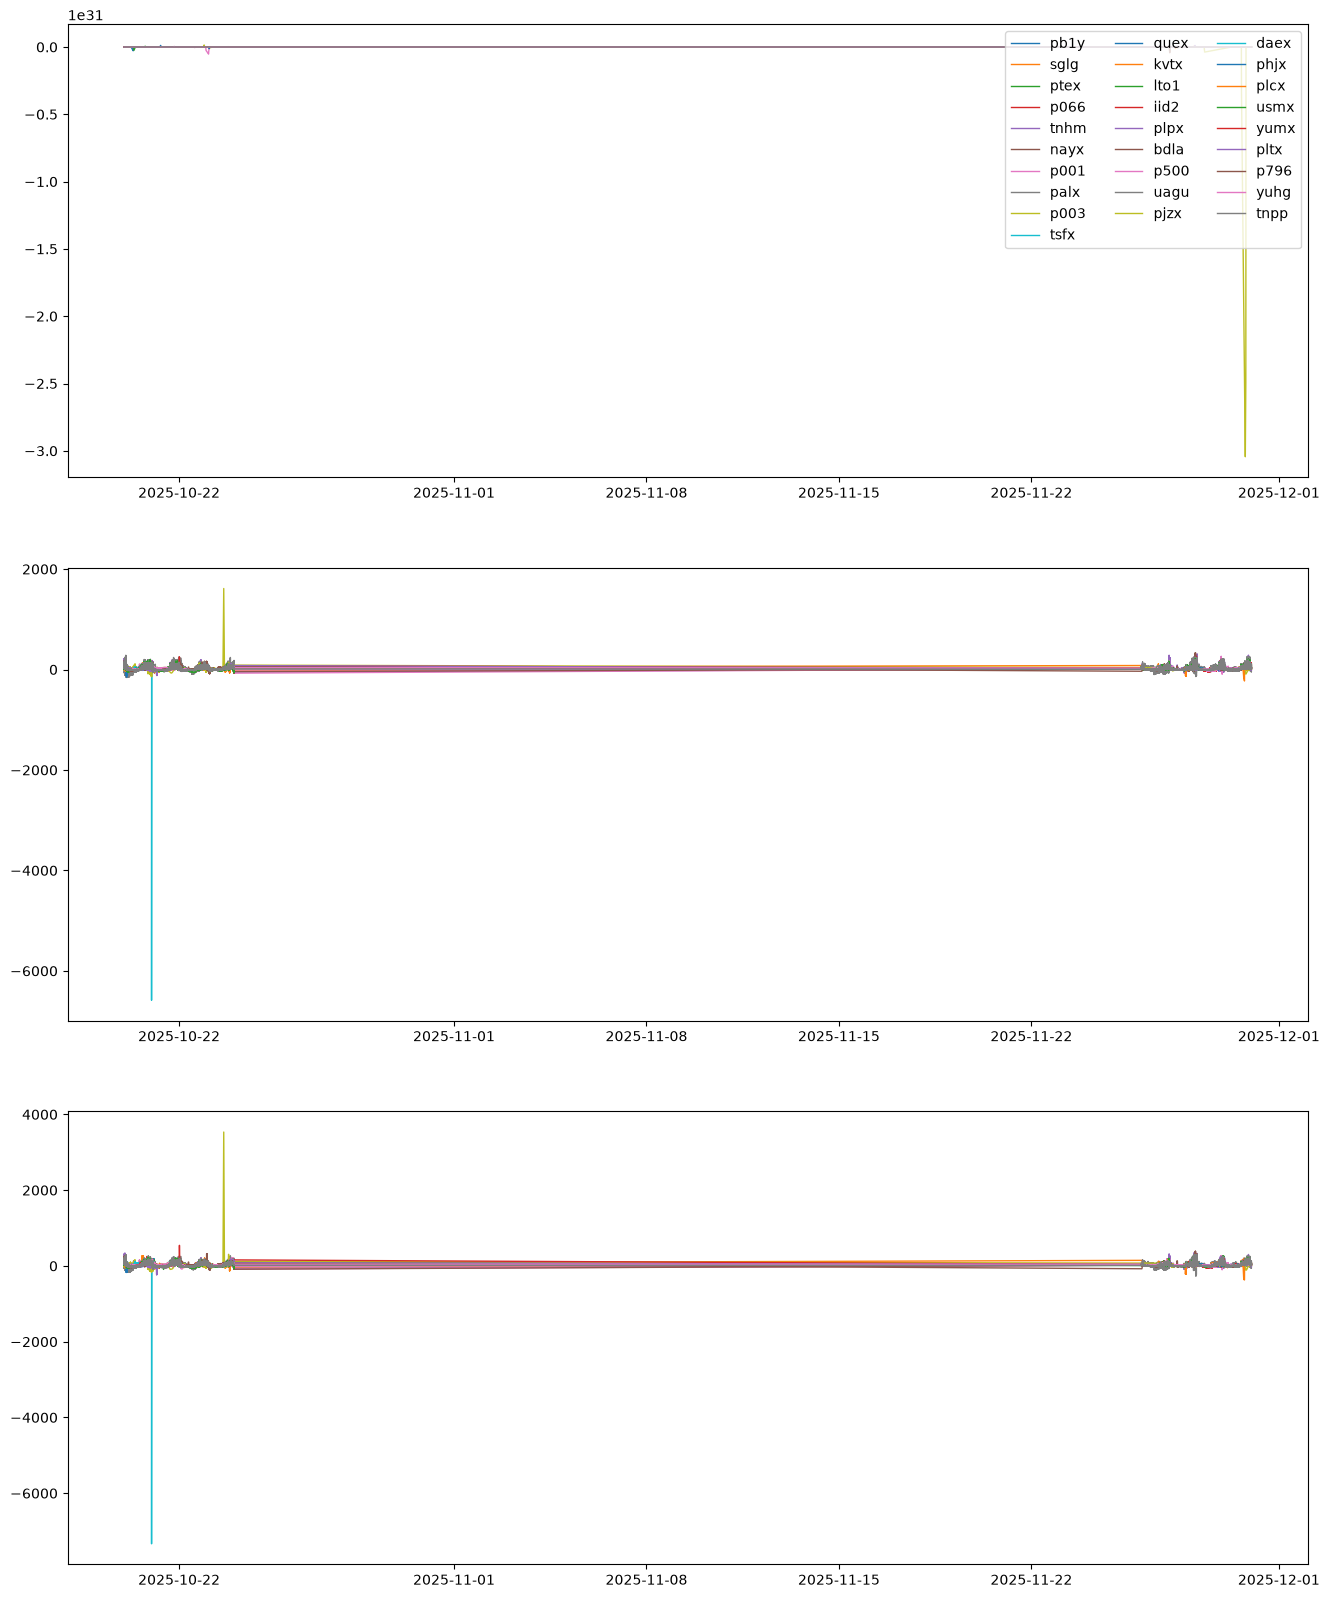

In [10]:
%matplotlib inline

# _, veq_ax = plt.subplots(1, 1, figsize=(16, 6))
# _, vtec_ax = plt.subplots(1, 1, figsize=(16, 6))
# _, stec_ax = plt.subplots(1, 1, figsize=(16, 6))
_, [veq_ax, vtec_ax, stec_ax] = plt.subplots(3, 1, figsize=(16, 20))
for i, (s_id, s_obs) in enumerate(tqdm(station_results.items())):
    # if i == 1:
    #     break
    s_obs = s_obs.with_columns(
        epoch=s_obs['epoch'].str.to_datetime() if s_obs.dtypes[0] == pl.String else s_obs['epoch'],
        vtec=s_obs['vtec'].cast(float),
        stec=s_obs['stec'].cast(float),
    )
    # sorted_obs = s_obs.sort(by='epoch_datetime')
    sorted_obs = s_obs.sort(by='epoch')
    sorted_obs = sorted_obs.filter(
        pl.col('id_arc_valid').is_not_null()
    )
    veq_ax.plot(sorted_obs['epoch'], sorted_obs['veq'], label=s_id, lw=1)
    vtec_ax.plot(sorted_obs['epoch'], sorted_obs['vtec'], label=s_id, lw=1)
    stec_ax.plot(sorted_obs['epoch'], sorted_obs['stec'], label=s_id, lw=1)

# for ax in [veq_ax, vtec_ax, stec_ax]:
#     ax.set_yscale('symlog')
#     ax.legend(loc='upper left')
veq_ax.legend(loc='upper right', ncols=3)
    
plt.show()

In [ ]:
%%script echo "skip; taking too long"

line_objects: list[go.Scatter] = []
for s_id, s_obs in tqdm(station_results.items()):
    sorted_obs = s_obs.sort(by='epoch')
    line_objects.append(go.Scatter(
        x=sorted_obs['epoch'].str.to_datetime().to_list(),
        y=sorted_obs['veq'].to_list(),
        name=s_id
    ))
    # break

fig = go.Figure(data=line_objects)
fig.show()

skip; taking too long
